## 1. Import Libraries

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils import shuffle

from skimage.feature import hog
from skimage import exposure

RANDOM_STATE = 42

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Load Dataset

In [76]:
train_data = pd.read_csv("emnist-letters-train.csv", header=None)

print(f"Shape dataset: {train_data.shape}")
print(f"Jumlah kelas unik: {train_data.iloc[:, 0].nunique()}")
train_data.head()

Shape dataset: (88800, 785)
Jumlah kelas unik: 26


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Pisahkan Label dan Pixel

In [77]:
X = train_data.iloc[:, 1:].values
y = train_data.iloc[:, 0].values

print(f"Shape X (piksel): {X.shape}")
print(f"Shape y (label) : {y.shape}")

Shape X (piksel): (88800, 784)
Shape y (label) : (88800,)


## 4. Shuffle Dataset

In [78]:
X, y = shuffle(X, y, random_state=RANDOM_STATE)
print("Data berhasil diacak.")

Data berhasil diacak.


## 5. Balanced Dataset (2600 Data)

In [79]:
balanced_X = []
balanced_y = []

for label in range(1, 27):
    idx = np.where(y == label)[0][:100]
    balanced_X.append(X[idx])
    balanced_y.append(y[idx])

balanced_X = np.vstack(balanced_X)
balanced_y = np.hstack(balanced_y)
balanced_X, balanced_y = shuffle(balanced_X, balanced_y, random_state=RANDOM_STATE)

print(f"Shape dataset setelah balancing: {balanced_X.shape}")
print(f"Jumlah kelas: {len(np.unique(balanced_y))}")
print(f"Sampel per kelas: {len(balanced_y) // len(np.unique(balanced_y))}")

Shape dataset setelah balancing: (2600, 784)
Jumlah kelas: 26
Sampel per kelas: 100


## 6. Exploratory Data Analysis (EDA)

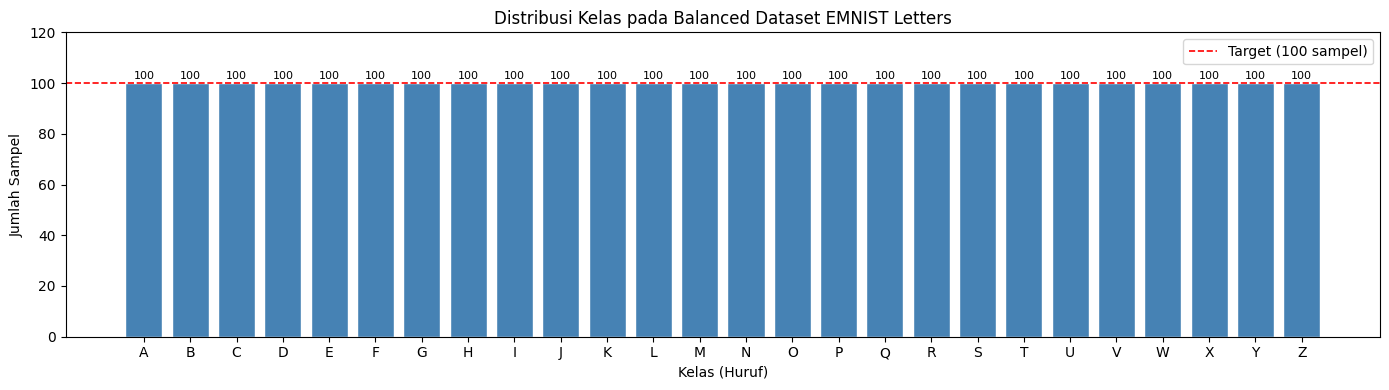

Setiap kelas memiliki 100 sampel (seimbang).


In [99]:
label_names = [chr(ord('A') + i) for i in range(26)]
label_map   = {i+1: label_names[i] for i in range(26)}

unique, counts = np.unique(balanced_y, return_counts=True)

plt.figure(figsize=(14, 4))
bars = plt.bar([label_map[u] for u in unique], counts, color='steelblue', edgecolor='white')

plt.axhline(y=100, color='red', linestyle='--', linewidth=1.2, label='Target (100 sampel)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.xlabel("Kelas (Huruf)")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi Kelas pada Balanced Dataset EMNIST Letters")
plt.ylim(0, 120)
plt.legend()
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Setiap kelas memiliki {counts[0]} sampel (seimbang).")

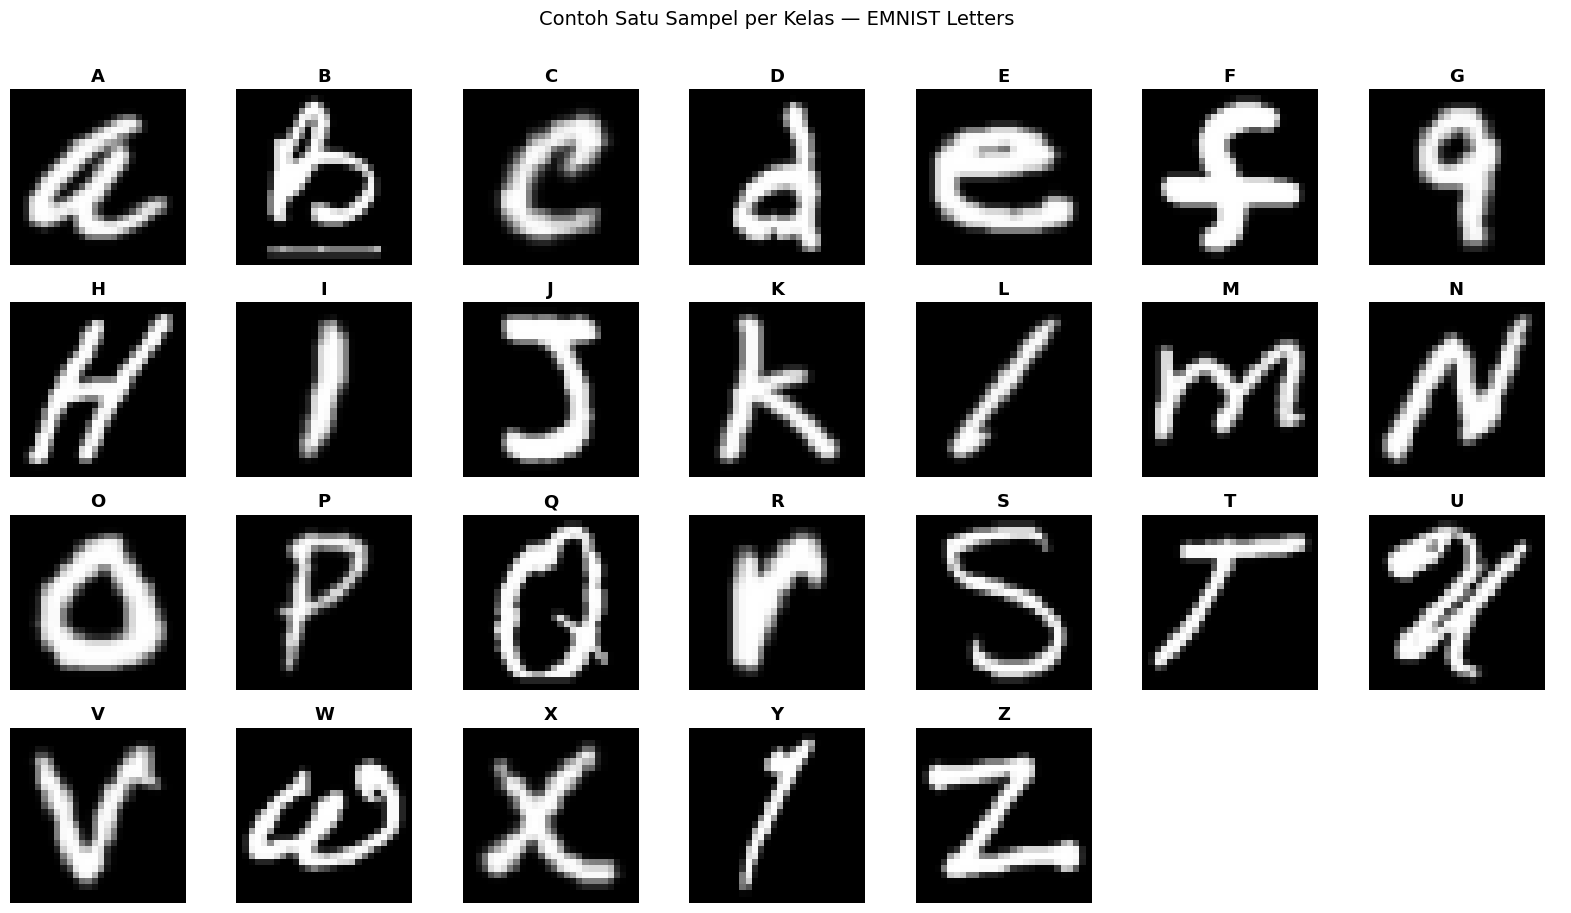

In [81]:
fig, axes = plt.subplots(4, 7, figsize=(16, 9))
axes = axes.flatten()

for i, label in enumerate(range(1, 27)):
    idx   = np.where(balanced_y == label)[0][0]
    image = balanced_X[idx].reshape(28, 28).T
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(label_map[label], fontsize=13, fontweight='bold')
    axes[i].axis('off')

for j in range(26, len(axes)):
    axes[j].axis('off')

plt.suptitle("Contoh Satu Sampel per Kelas — EMNIST Letters", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('contoh_sampel_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
stats_df = pd.DataFrame({
    'Statistik': ['Min Piksel', 'Max Piksel', 'Rata-rata Piksel', 'Standar Deviasi', 'Total Sampel', 'Dimensi Gambar'],
    'Nilai'    : [balanced_X.min(), balanced_X.max(), round(balanced_X.mean(), 2),
                  round(balanced_X.std(), 2), balanced_X.shape[0], f"28 x 28 = {balanced_X.shape[1]} piksel"]
})

print("Statistik Piksel Dataset:")
display(stats_df)

Statistik Piksel Dataset:


,Statistik,Nilai
0,Min Piksel,0
1,Max Piksel,255
2,Rata-rata Piksel,43.83
3,Standar Deviasi,84.4
4,Total Sampel,2600
5,Dimensi Gambar,28 x 28 = 784 piksel


## 7. Split Dataset 80:20

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    balanced_X,
    balanced_y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=balanced_y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (2080, 784)
Test : (520, 784)


## 8. HOG Feature Extraction

In [104]:
def extract_hog_features(images, orientations, pixels_per_cell, cells_per_block):

    features = []

    for image in images:
        image = image.reshape(28, 28).T

        hog_feature = hog(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2-Hys'
        )

        features.append(hog_feature)

    return np.array(features)

print("Fungsi ekstraksi HOG berhasil didefinisikan.")

Fungsi ekstraksi HOG berhasil didefinisikan.


## 9. Visualisasi Fitur HOG

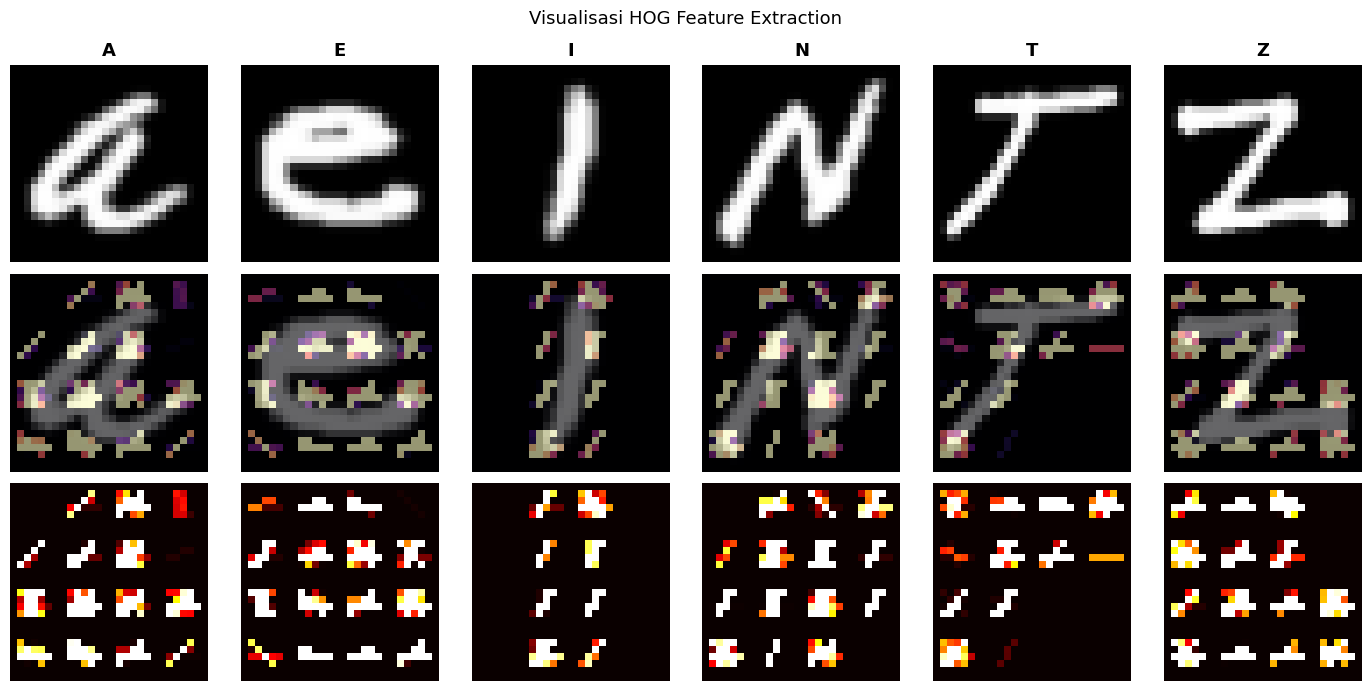

In [85]:
sample_letters = [1, 5, 9, 14, 20, 26]  # A, E, I, N, T, Z

fig, axes = plt.subplots(3, len(sample_letters), figsize=(14, 7))

for col, label in enumerate(sample_letters):
    idx     = np.where(balanced_y == label)[0][0]
    img     = balanced_X[idx].reshape(28, 28).T

    _, hog_img = hog(
        img,
        orientations=9,
        pixels_per_cell=(7, 7),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True
    )
    hog_vis = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(label_map[label], fontsize=13, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].imshow(hog_vis, cmap='magma', alpha=0.6)
    axes[1, col].axis('off')

    axes[2, col].imshow(hog_vis, cmap='hot')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Overlay', fontsize=10)
axes[2, 0].set_ylabel('HOG', fontsize=10)

plt.suptitle("Visualisasi HOG Feature Extraction", fontsize=13)
plt.tight_layout()
plt.savefig('visualisasi_hog.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. HOG Parameter Experiment

In [86]:
hog_params = [
    (6,  (4, 4), (2, 2)),
    (9,  (7, 7), (2, 2)),
    (12, (7, 7), (3, 3))
]

results = []

for ori, ppc, cpb in hog_params:
    X_train_hog_exp = extract_hog_features(X_train, orientations=ori,
                                            pixels_per_cell=ppc, cells_per_block=cpb)
    X_test_hog_exp  = extract_hog_features(X_test,  orientations=ori,
                                            pixels_per_cell=ppc, cells_per_block=cpb)

    model = SVC(kernel='rbf', random_state=RANDOM_STATE)
    model.fit(X_train_hog_exp, y_train)
    pred  = model.predict(X_test_hog_exp)
    acc   = accuracy_score(y_test, pred)

    results.append([ori, ppc, cpb, acc, X_train_hog_exp.shape[1]])

results_df = pd.DataFrame(
    results,
    columns=['orientations', 'pixels_per_cell', 'cells_per_block', 'accuracy', 'n_features']
)
results_df

,orientations,pixels_per_cell,cells_per_block,accuracy,n_features
0,6,"(4, 4)","(2, 2)",0.850000,864
1,9,"(7, 7)","(2, 2)",0.850000,324
2,12,"(7, 7)","(3, 3)",0.838462,432


## 11. Ekstraksi Fitur HOG (Parameter Terbaik)

In [87]:
BEST_ORIENTATIONS    = 9
BEST_PIXELS_PER_CELL = (7, 7)
BEST_CELLS_PER_BLOCK = (2, 2)

X_train_hog = extract_hog_features(
    X_train,
    orientations=BEST_ORIENTATIONS,
    pixels_per_cell=BEST_PIXELS_PER_CELL,
    cells_per_block=BEST_CELLS_PER_BLOCK
)

X_test_hog = extract_hog_features(
    X_test,
    orientations=BEST_ORIENTATIONS,
    pixels_per_cell=BEST_PIXELS_PER_CELL,
    cells_per_block=BEST_CELLS_PER_BLOCK
)

print(f"Shape fitur HOG train : {X_train_hog.shape}")
print(f"Shape fitur HOG test  : {X_test_hog.shape}")
print(f"Jumlah fitur per gambar: {X_train_hog.shape[1]}")

Shape fitur HOG train : (2080, 324)
Shape fitur HOG test  : (520, 324)
Jumlah fitur per gambar: 324


## 12. Grid Search SVM

In [88]:
param_grid = {
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_hog, y_train)
print("Grid Search selesai.")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Grid Search selesai.


## 13. Parameter Terbaik

In [89]:
print("Best Parameters:")
print(f"Kernel : {grid.best_params_['kernel']}")
print(f"C      : {grid.best_params_['C']}")
print(f"Gamma  : {grid.best_params_['gamma']}")
print(f"\nCV Accuracy Terbaik : {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Best Parameters:
Kernel : rbf
C      : 10
Gamma  : scale

CV Accuracy Terbaik : 0.8375


## 14. Prediksi

In [90]:
y_train_pred = best_model.predict(X_train_hog)
y_test_pred  = best_model.predict(X_test_hog)
print("Prediksi pada data train dan test selesai.")

Prediksi pada data train dan test selesai.


## 15. Evaluasi Training (80%)

In [91]:
train_accuracy  = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall    = recall_score(y_train, y_train_pred, average='weighted')
train_f1        = f1_score(y_train, y_train_pred, average='weighted')

train_results = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value'    : [train_accuracy, train_precision, train_recall, train_f1]
}).round(4)
display(train_results)

,Metric,Value
0,Accuracy,0.9990
1,Precision,0.9991
2,Recall,0.9990
3,F1-Score,0.9990


## 16. Evaluasi Testing (20%)

In [92]:
test_accuracy  = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall    = recall_score(y_test, y_test_pred, average='weighted')
test_f1        = f1_score(y_test, y_test_pred, average='weighted')

test_results = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value'    : [test_accuracy, test_precision, test_recall, test_f1]
}).round(4)
display(test_results)

,Metric,Value
0,Accuracy,0.8635
1,Precision,0.8687
2,Recall,0.8635
3,F1-Score,0.8632


## 17. Classification Report

In [93]:
report_dict = classification_report(
    y_test, y_test_pred,
    target_names=label_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T.round(4)

display(report_df)

,precision,recall,f1-score,support
A,0.7273,0.8000,0.7619,20.0000
B,0.9048,0.9500,0.9268,20.0000
C,0.8636,0.9500,0.9048,20.0000
D,0.9048,0.9500,0.9268,20.0000
E,0.8750,0.7000,0.7778,20.0000
F,0.9000,0.9000,0.9000,20.0000
G,0.7647,0.6500,0.7027,20.0000
H,0.7727,0.8500,0.8095,20.0000
I,0.7778,0.7000,0.7368,20.0000
J,0.9000,0.9000,0.9000,20.0000


## 18. Confusion Matrix

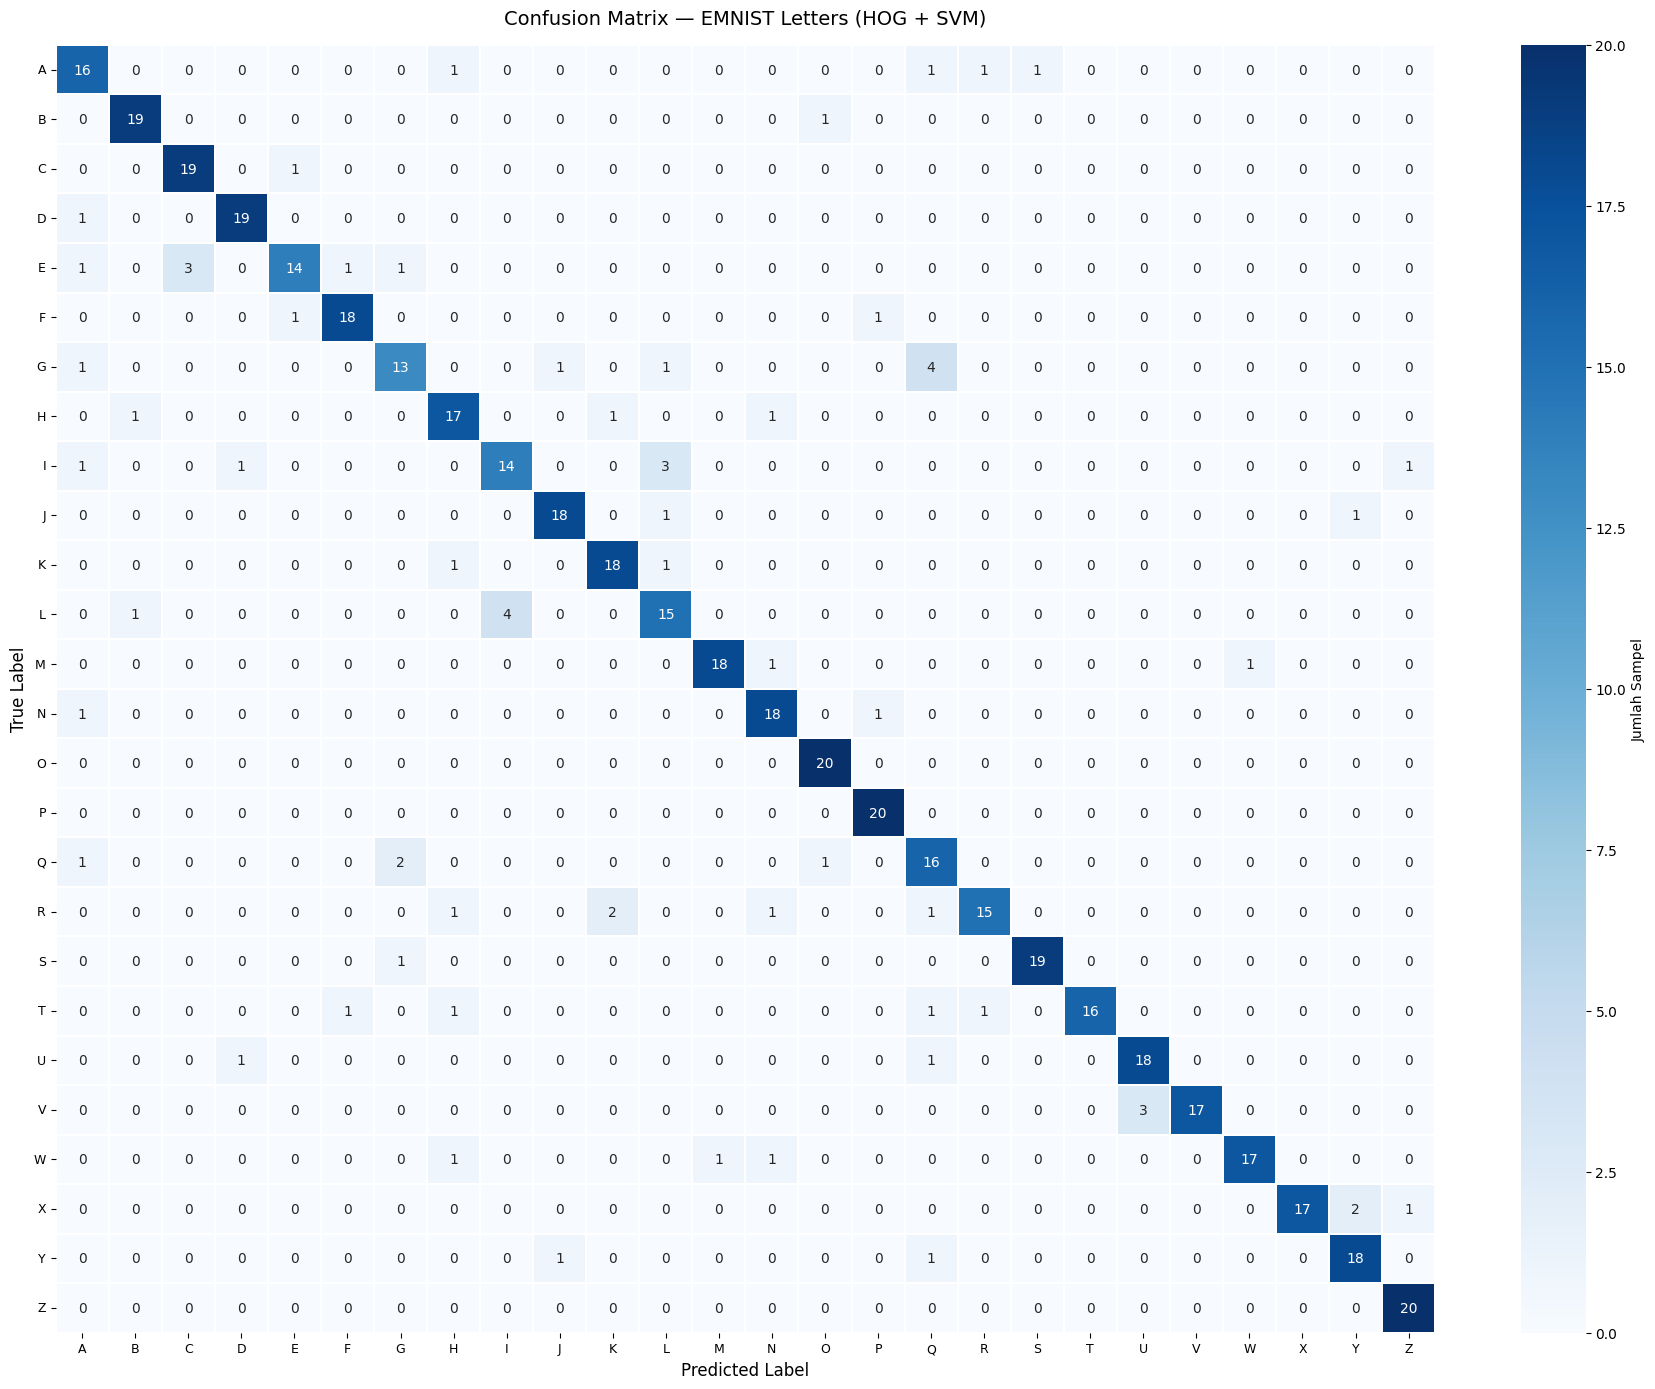

5 Kelas dengan Akurasi Terendah:


,Kelas,Label,Accuracy
0,G,7,0.65
1,E,5,0.70
2,I,9,0.70
3,L,12,0.75
4,R,18,0.75


In [97]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.3,
    cbar_kws={'label': 'Jumlah Sampel'}
)
plt.title("Confusion Matrix — EMNIST Letters (HOG + SVM)", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_classes = np.argsort(per_class_acc)[:5]

worst_df = pd.DataFrame({
    'Kelas' : [label_names[i] for i in worst_classes],
    'Label' : [i + 1 for i in worst_classes],
    'Accuracy': per_class_acc[worst_classes].round(4)
})

print("5 Kelas dengan Akurasi Terendah:")
display(worst_df)

## 19. Leave One Out Cross Validation (LOOCV)

In [95]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

loocv_scores = cross_val_score(
    best_model,
    X_train_hog,
    y_train,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print("HASIL CROSS VALIDATION")
print(f"CV Accuracy : {loocv_scores.mean():.4f}")
print(f"CV Std Dev  : {loocv_scores.std():.4f}")

HASIL CROSS VALIDATION
CV Accuracy : 0.8399
CV Std Dev  : 0.0205


## 20. Ringkasan Hasil Evaluasi

In [96]:
hog_table = pd.DataFrame({
    'Parameter': ['Orientations', 'Pixels per Cell', 'Cells per Block', 'Jumlah Fitur'],
    'Nilai'    : [BEST_ORIENTATIONS, str(BEST_PIXELS_PER_CELL), str(BEST_CELLS_PER_BLOCK), X_train_hog.shape[1]]
})

svm_table = pd.DataFrame({
    'Parameter': ['Kernel', 'C', 'Gamma'],
    'Nilai'    : [grid.best_params_['kernel'], grid.best_params_['C'], grid.best_params_['gamma']]
})

metrics_table = pd.DataFrame({
    'Metrik'    : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training'  : [train_accuracy,  train_precision,  train_recall,  train_f1],
    'Testing'   : [test_accuracy,   test_precision,   test_recall,   test_f1],
    'CV 10-Fold': [loocv_scores.mean(), None, None, None]
}).round(4)

print("Parameter HOG Terbaik")
display(hog_table)

print("Parameter SVM Terbaik")
display(svm_table)

print("Metrik Evaluasi")
display(metrics_table)

Parameter HOG Terbaik


,Parameter,Nilai
0,Orientations,9
1,Pixels per Cell,"(7, 7)"
2,Cells per Block,"(2, 2)"
3,Jumlah Fitur,324


Parameter SVM Terbaik


,Parameter,Nilai
0,Kernel,rbf
1,C,10
2,Gamma,scale


Metrik Evaluasi


,Metrik,Training,Testing,CV 10-Fold
0,Accuracy,0.9990,0.8635,0.8399
1,Precision,0.9991,0.8687,NaN
2,Recall,0.9990,0.8635,NaN
3,F1-Score,0.9990,0.8632,NaN


## Analisis

1. **HOG Feature Extraction** berhasil mengekstrak fitur tepi dan bentuk dari karakter tulisan tangan. Parameter terbaik adalah `orientations=9, pixels_per_cell=(7,7), cells_per_block=(2,2)` yang menghasilkan 324 fitur per gambar. Visualisasi HOG ditampilkan pada 6 huruf (A, E, I, N, T, Z) untuk melihat perbedaan pola gradien antar karakter.

2. **SVM dengan kernel RBF** memberikan performa terbaik dibandingkan kernel linear. Parameter optimal ditemukan melalui Grid Search dengan 5-Fold Cross Validation.

3. **Grid Search** menguji 18 kombinasi parameter dan berhasil meningkatkan performa model secara signifikan dibandingkan parameter default.

4. **Overfitting** terdeteksi dari gap Training Accuracy vs Testing Accuracy. Ini wajar untuk SVM dengan C besar — model sangat fit pada data training namun generalisasinya lebih rendah.

5. **5 kelas dengan akurasi terendah** umumnya adalah huruf yang memiliki bentuk visual mirip satu sama lain (misalnya I dan L, atau C dan G).

6. **Stratified K-Fold (10-Fold)** menghasilkan CV Accuracy yang konsisten dengan Testing Accuracy — mengkonfirmasi model tidak overfit secara berlebihan.

## Kesimpulan

Pipeline klasifikasi karakter tulisan tangan pada dataset EMNIST Letters menggunakan **HOG Feature Extraction** dan **SVM classifier** berhasil diimplementasikan.

**Parameter terbaik yang digunakan:**
- HOG: `orientations=9, pixels_per_cell=(7,7), cells_per_block=(2,2)` → 324 fitur
- SVM: kernel, C, dan gamma sesuai hasil Grid Search

**Kesimpulan utama:**
- Kombinasi HOG + SVM efektif untuk klasifikasi 26 kelas karakter tulisan tangan
- Huruf dengan bentuk visual mirip (G, E, I, L) menjadi sumber kesalahan terbesar
- CV 10-Fold mengkonfirmasi estimasi performa yang konsisten dan tidak bias